In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI
from smt.sampling_methods import LHS


import os
import sys

# Changing directory to FEWNEW/work
# to import stuffs
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import loglike_timemax  # TIME-MAXIMIZED VERSION
# import modeselectoralt
import parismc
# import gc
import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

# GPU configuration 
use_gpu = True
force_backend = "cuda12x"  
dt = 10     # Time step
T = 1/12     # Total time
print(f"Using dt = {dt} seconds, T = {T} years")

print('Initializing waveform generator...')
# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": force_backend # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": force_backend,  # Force GPU
    # "assume_positive_m": True  # if we assume positive m, it will generate negative m for all m>0
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs_comb = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
}

sum_kwargs_sep = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
    "separate_modes": True,
}

print("Creating GenerateEMRIWaveform class...")
# Kerr eccentric flux
waveform_gen_comb = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_comb,
    use_gpu=use_gpu
)

# Kerr eccentric flux
waveform_gen_sep = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_sep,
    use_gpu=use_gpu
)


print('Done initializing waveform generator.')

print("Creating GravWaveAnalysis class...")
gwf = GWfuncs.GravWaveAnalysis(T, dt)

print("Initializing loglike class...")


# Source parameters
m1 = 1e6
m2 = 3e1
a = 0.7
p0 = 11.7 
e0 = 0.4
xI0 = 1.0
dist = 0.9  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = (m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

# n-indexed mode selection parameters
n_vals = np.arange(-1,6)  # n from -1 to 10
ell = 2  # quadrupole only

# NOTE: change verbose argument for debugging
# Using n-indexed mode selection
loglike_obj = loglike_timemax.LogLikeTimeMax(
    params_star,
    waveform_gen_comb,
    gwf,
    verbose=False,
    waveform_gen_sep=waveform_gen_sep,
    ell=ell,
    n_vals=n_vals,
    M_mode=None  # No SNR filtering, use all n-groups
)

print('Done initializing loglike class.')
print('Calculating SNR...')
data = loglike_obj.signal
data_snr = gwf.rhostat(data)
print('SNR calculated:', data_snr)
print("Setting up log_density and prior functions...")


def log_density(params):
    params = np.asarray(params)

    n_samples = params.shape[0] 
    log_likes = np.zeros(n_samples)


    for i in range(n_samples):
        logm1, logm2, a, p0, e0 = params[i]
        m1 = 10**logm1
        m2 = 10**logm2

        loglike = loglike_obj(np.array([m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]))
        log_likes[i] = 10*loglike #NOTE: scaled 10x

    return log_likes

def prior_transform(u):
    logm1lim = [5.9, 6.2]
    logm2lim = [1.3,1.6]
    alim = [0.4, 0.95]
    p0lim = [9.0, 14.5]
    e0lim = [0.3, 0.5]

    transformed = np.zeros_like(u)

    # Uniform in log for masses

    # m1
    transformed[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]

    # m2
    transformed[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]

    # Linear in others 

    # a
    transformed[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]

    # p0
    transformed[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0] 

    # e0
    transformed[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]

    
    return transformed

    

print('Done setting up log-likelihood and prior.')

Using dt = 10 seconds, T = 0.08333333333333333 years
Initializing waveform generator...
Creating GenerateEMRIWaveform class...
Done initializing waveform generator.
Creating GravWaveAnalysis class...
Initializing loglike class...
Done initializing loglike class.
Calculating SNR...
SNR calculated: 5.97163342241979
Setting up log_density and prior functions...
Done setting up log-likelihood and prior.


In [2]:
groups = [
    [(2,-2,-1),(2,-1,-1),  (2,0,-1), (2,1,-1), (2,2,-1)],#0
    [(2,-2,0),(2,-1,0),  (2,0,0), (2,1,0), (2,2,0)],#1
    [(2,-2,1),(2,-1,1),  (2,0,1), (2,1,1), (2,2,1)],#2
    [(2,-2,2),(2,-1,2),  (2,0,2), (2,1,2), (2,2,2)],#3
    [(2,-2,3),(2,-1,3),  (2,0,3), (2,1,3), (2,2,3)],#4
    [(2,-2,4),(2,-1,4),  (2,0,4), (2,1,4), (2,2,4)],#5
    [(2,-2,5),(2,-1,5),  (2,0,5), (2,1,5), (2,2,5)],#6
]

In [3]:
proc1_maxld_pt = np.array([[ 6.02495386,  1.46072375,  0.78132966, 11.19827629,  0.40443896]])
# proc2_maxld_pt = np.array([[ 6.02495386,  1.46072375,  0.78132966, 11.19827629,  0.40443896]])

In [4]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0]  # Convert from (1,5) to (5,)
# proc2_maxld_pt_1d = proc2_maxld_pt[0]  # Convert from (1,5) to (5,)
true_pt = np.array(param_true)


n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]
# line_points_proc2 = proc2_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc2_maxld_pt_1d)[:, np.newaxis]


In [5]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [6]:
# logden_theory_proc2 = []
# logden_theory_proc2.append(log_density(np.array(line_points_proc2).T))


In [7]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()
# logden_theory_proc2 = np.array(logden_theory_proc2).flatten()
logden_theory_proc1

array([59.53900157, 59.41901643, 59.04409741, 59.24808092, 59.13729579,
       59.07837814, 58.84174798, 58.97735451, 58.8427705 , 58.61607312,
       58.4429213 , 58.40183314, 58.35779379, 58.42952333, 58.51252294,
       58.46442993, 58.112842  , 58.43005032, 58.2080641 , 58.43879271,
       58.1802927 , 58.24110708, 58.3859497 , 58.39682345, 58.38077079,
       58.38483987, 58.39708039, 58.34642375, 58.11737675, 58.30913792,
       58.40006134, 58.14179551, 58.43294413, 58.31236549, 58.27530364,
       58.52306799, 58.60480555, 58.62791714, 58.67676891, 58.73587774,
       58.82881767, 58.88440182, 58.79260743, 58.82319511, 59.12385585,
       58.81238236, 59.24588129, 59.05157818, 59.25677012, 59.48043158])

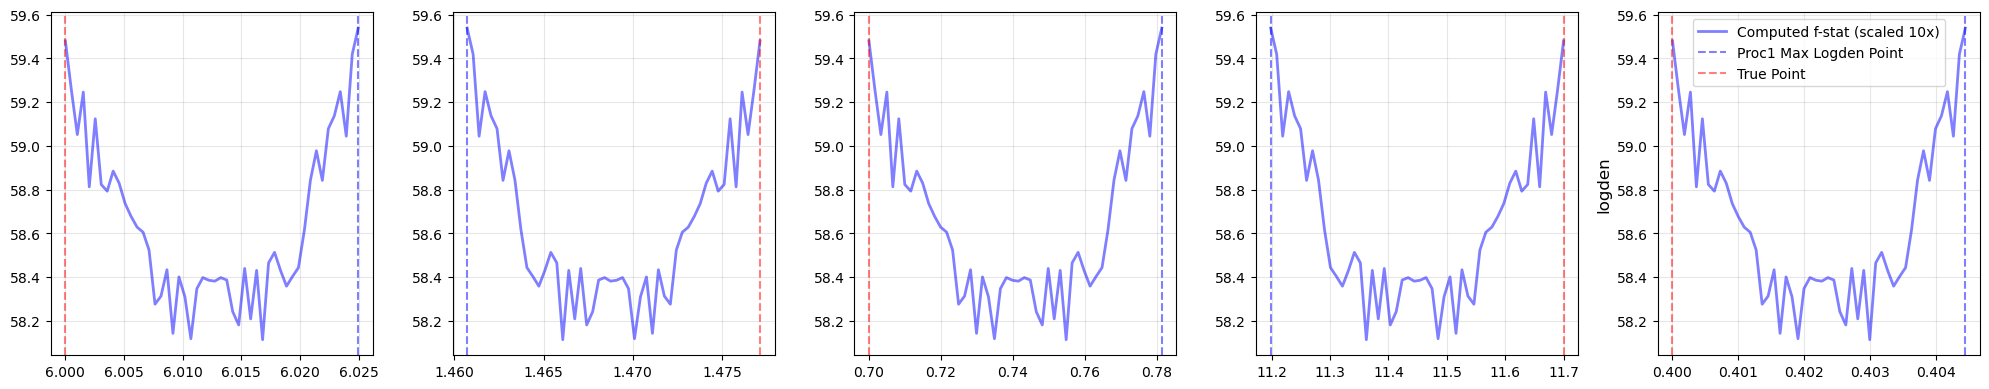

In [8]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat (scaled 10x)')
    # ax.plot(line_points_proc2[dim], logden_theory_proc2, '-', 
    #         color='darkorange', alpha=0.5, linewidth=2, label='Theory Proc2')
    

    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    # ax.axvline(proc2_maxld_pt_1d[dim], color='orange', linestyle='--', 
    #            alpha=0.5, label=f'Proc2 Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    # ax.set_xlabel(labels[dim], fontsize=12)
#     ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [9]:
templates_proc1 = []
for point in line_points_proc1.T:
    logm1, logm2, a, p0, e0 = point
    m1 = 10**logm1
    m2 = 10**logm2
    template = waveform_gen_comb(m1, m2, a, p0, e0, xI0, dist, 
                                 qS, phiS, qK, phiK, 
                                 Phi_phi0, Phi_theta0, Phi_r0,
                                 dt=dt, T=T)
    templates_proc1.append(template)

In [10]:
X_proc1 = []
for template in templates_proc1:
    X = gwf.Xstat_timemax(data, template)
    X_proc1.append(X.get())

In [11]:
# templates_proc2 = []
# for point in line_points_proc2.T:
#     logm1, logm2, a, p0, e0 = point
#     m1 = 10**logm1
#     m2 = 10**logm2
#     template = waveform_gen_comb(m1, m2, a, p0, e0, xI0, dist, 
#                                  qS, phiS, qK, phiK, 
#                                  Phi_phi0, Phi_theta0, Phi_r0,
#                                  dt=dt, T=T)
#     templates_proc2.append(template)

In [12]:
# X_proc2 = []
# for template in templates_proc2:
#     X = gwf.Xstat(data, template)
#     X_proc2.append(X.get())

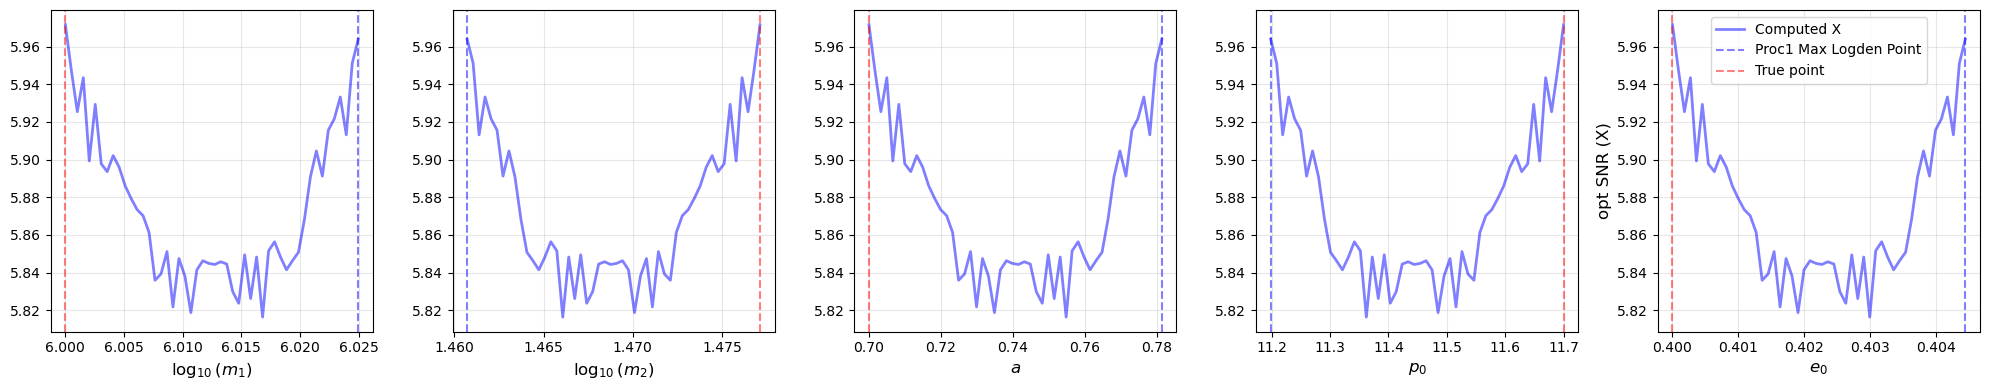

In [13]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
plt.ylabel('opt SNR (X)', fontsize=12)

for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], X_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed X')
#     ax.plot(line_points_proc2[dim], X_proc2, '-', 
#             color='darkorange', alpha=0.5, linewidth=2, label='Theory Proc2')
    

    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
#     ax.axvline(proc2_maxld_pt_1d[dim], color='orange', linestyle='--', 
#                alpha=0.5, label=f'Proc2 point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('opt SNR (X)', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [14]:
amp = getattr(waveform_gen_sep.waveform_generator, 'amplitude_generator', None)    
mode_forms = []

for point in line_points_proc1.T:
    logm1, logm2, a, p0, e0 = point
    m1 = 10**logm1
    m2 = 10**logm2
    
    # Generate waveforms for each GROUP (not combined)
    waveforms_per_group = []
    for group in groups:
        mode_form_group = waveform_gen_sep(m1, m2, a, p0, e0, xI0, dist,
                                          qS, phiS, qK, phiK, 
                                          Phi_phi0, Phi_theta0, Phi_r0,
                                          dt=dt, T=T,
                                          mode_selection=group,  # Pass group list
                                          include_minus_mkn=False)
        # Sum all modes within this group
        mode_form_summed = np.sum(mode_form_group, axis=1)
        waveforms_per_group.append(mode_form_summed)
    
    # Stack into array: shape (N_samples, N_groups)
    mode_form = np.stack(waveforms_per_group, axis=1)
    mode_forms.append(mode_form)


In [15]:
rhostats_proc1 = []
for hm_arr in mode_forms:
    rhostats_proc1.append(gwf.rhostat_modes(hm_arr.T))

In [16]:
rhostats_proc1

[array([0.27849912, 0.52145581, 1.05868239, 1.58574349, 2.65593238,
        3.47660332, 2.62516783]),
 array([0.27939501, 0.52121289, 1.05806105, 1.58685261, 2.65459931,
        3.47467843, 2.62368962]),
 array([0.28013322, 0.52156949, 1.05662056, 1.58758214, 2.6540979 ,
        3.47291931, 2.62210601]),
 array([0.28067441, 0.52242548, 1.05521503, 1.58722179, 2.65383966,
        3.47151477, 2.62059026]),
 array([0.28100428, 0.52356815, 1.05451225, 1.58600275, 2.653078  ,
        3.47010995, 2.6191655 ]),
 array([0.2811289 , 0.52478259, 1.0547657 , 1.58471498, 2.65172896,
        3.46842859, 2.61769566]),
 array([0.28106916, 0.52588229, 1.055803  , 1.58403437, 2.65027482,
        3.46660204, 2.61614157]),
 array([0.28085528, 0.52674062, 1.05721045, 1.58414933, 2.64919965,
        3.46491572, 2.61459878]),
 array([0.28052191, 0.5273018 , 1.05855193, 1.58479857, 2.64860988,
        3.4634662 , 2.61313359]),
 array([0.2801043 , 0.52757057, 1.05951702, 1.58553692, 2.64826889,
        3.4621

In [17]:
Xm_proc1 = []
for idx, hm_arr in enumerate(mode_forms):
    X_mode = gwf.Xmstat_timemax(data, hm_arr.T, rhostats_proc1[idx])
    Xm_proc1.append(X_mode)

In [18]:
chi2_proc1 = []
for i in range(len(mode_forms)):
    chi2 = gwf.chi_sq(Xm_proc1[i], rhostats_proc1[i])
    chi2_proc1.append(chi2.get())

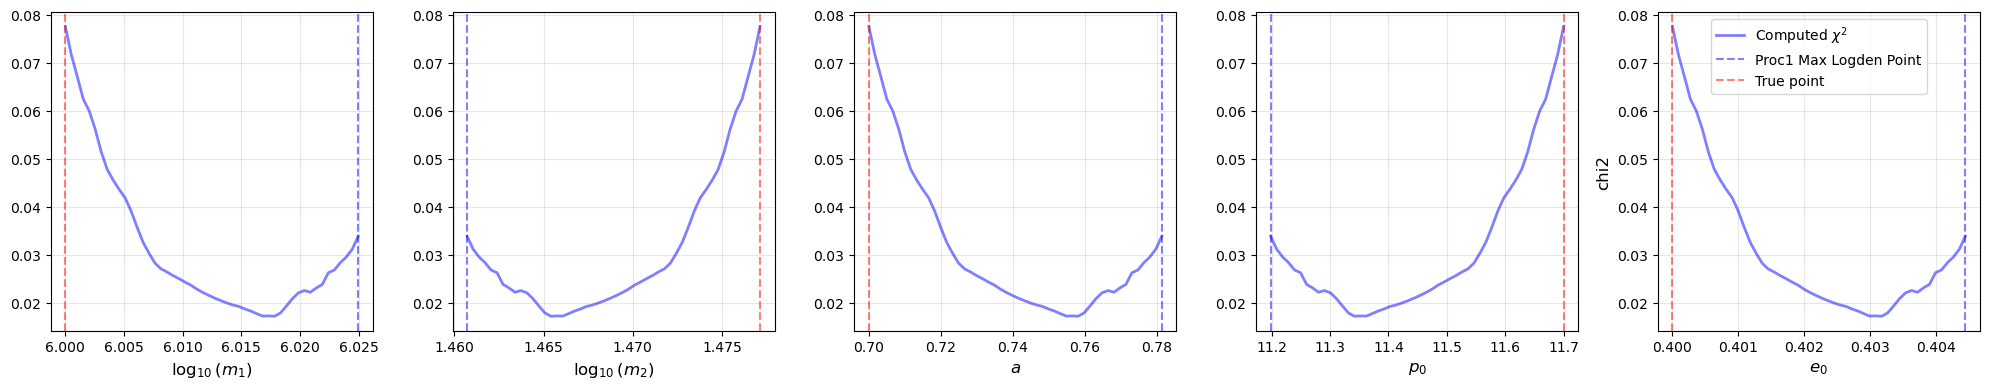

In [19]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
plt.ylabel('chi2', fontsize=12)

for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], chi2_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label=r'Computed $\chi^2$')
    # ax.plot(line_points_proc2[dim], chi2_proc2, '-', 
    #         color='darkorange', alpha=0.5, linewidth=2, label='Theory Proc2')
    

    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    # ax.axvline(proc2_maxld_pt_1d[dim], color='orange', linestyle='--', 
    #            alpha=0.5, label=f'Proc2 point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('opt SNR (X)', fontsize=12)
    ax.grid(True, alpha=0.3)
 
plt.legend()
plt.tight_layout()


In [20]:
chi2_proc1

[array(0.03387394),
 array(0.03118445),
 array(0.02955846),
 array(0.02837276),
 array(0.02685544),
 array(0.02628305),
 array(0.02386149),
 array(0.02313007),
 array(0.02222524),
 array(0.0225815),
 array(0.022102),
 array(0.02090029),
 array(0.01937759),
 array(0.01792658),
 array(0.01723252),
 array(0.01730296),
 array(0.01726609),
 array(0.01777765),
 array(0.01832677),
 array(0.01876235),
 array(0.01928318),
 array(0.01957875),
 array(0.02000339),
 array(0.0204841),
 array(0.02099271),
 array(0.02156683),
 array(0.02218001),
 array(0.02287162),
 array(0.02370352),
 array(0.0243479),
 array(0.02504961),
 array(0.02569309),
 array(0.02644581),
 array(0.02708833),
 array(0.02827753),
 array(0.03033137),
 array(0.03263055),
 array(0.03575016),
 array(0.03911429),
 array(0.04186451),
 array(0.04361226),
 array(0.04555011),
 array(0.04778572),
 array(0.05144041),
 array(0.05612491),
 array(0.05991072),
 array(0.06240275),
 array(0.06706812),
 array(0.07161805),
 array(0.07751389)]

In [21]:
rhostats_proc1

[array([0.27849912, 0.52145581, 1.05868239, 1.58574349, 2.65593238,
        3.47660332, 2.62516783]),
 array([0.27939501, 0.52121289, 1.05806105, 1.58685261, 2.65459931,
        3.47467843, 2.62368962]),
 array([0.28013322, 0.52156949, 1.05662056, 1.58758214, 2.6540979 ,
        3.47291931, 2.62210601]),
 array([0.28067441, 0.52242548, 1.05521503, 1.58722179, 2.65383966,
        3.47151477, 2.62059026]),
 array([0.28100428, 0.52356815, 1.05451225, 1.58600275, 2.653078  ,
        3.47010995, 2.6191655 ]),
 array([0.2811289 , 0.52478259, 1.0547657 , 1.58471498, 2.65172896,
        3.46842859, 2.61769566]),
 array([0.28106916, 0.52588229, 1.055803  , 1.58403437, 2.65027482,
        3.46660204, 2.61614157]),
 array([0.28085528, 0.52674062, 1.05721045, 1.58414933, 2.64919965,
        3.46491572, 2.61459878]),
 array([0.28052191, 0.5273018 , 1.05855193, 1.58479857, 2.64860988,
        3.4634662 , 2.61313359]),
 array([0.2801043 , 0.52757057, 1.05951702, 1.58553692, 2.64826889,
        3.4621

In [22]:
betas_proc1 = []
for rho_arr in rhostats_proc1:
    rho_tot = np.sqrt(np.sum(rho_arr**2))
    rho_dom_M = np.max(rho_arr)
    beta = gwf.calc_beta(rho_dom_M, rho_tot)
    betas_proc1.append(beta.get())

betas_proc1 = np.array(betas_proc1)

In [23]:
f_theory = []
for i in range(0, 50):
    f_theor = X_proc1[i] * np.exp(-0.5 * betas_proc1[i] * chi2_proc1[i])
    print(f_theor)
    f_theory.append(f_theor)

5.949917976512649
5.93824337257634
5.900965535860083
5.921490881606376
5.910593161740136
5.9047678081818
5.881397602865492
5.895039335632882
5.8816959735560035
5.858997453321839
5.841745742163604
5.837775038964866
5.833546470194693
5.8408838601429425
5.8492624616250515
5.844448983794709
5.8093087024862005
5.840961685708402
5.818709026113342
5.841724045073595
5.815824257741507
5.821869771552545
5.836300103375949
5.837332505332879
5.835670464130323
5.836012615216663
5.837167443103535
5.832026749505606
5.809039780623686
5.828135805408346
5.837145918580376
5.811260621996987
5.840275801571463
5.828150724764687
5.824310135247724
5.8488374651771355
5.856744719881164
5.858702410041956
5.863207376564539
5.868807266887709
5.877897791279058
5.883228829419154
5.8737997204248655
5.8764400889379225
5.905948453682552
5.874417896517675
5.917443621040047
5.89751068636442
5.917487255085826
5.93915375221442


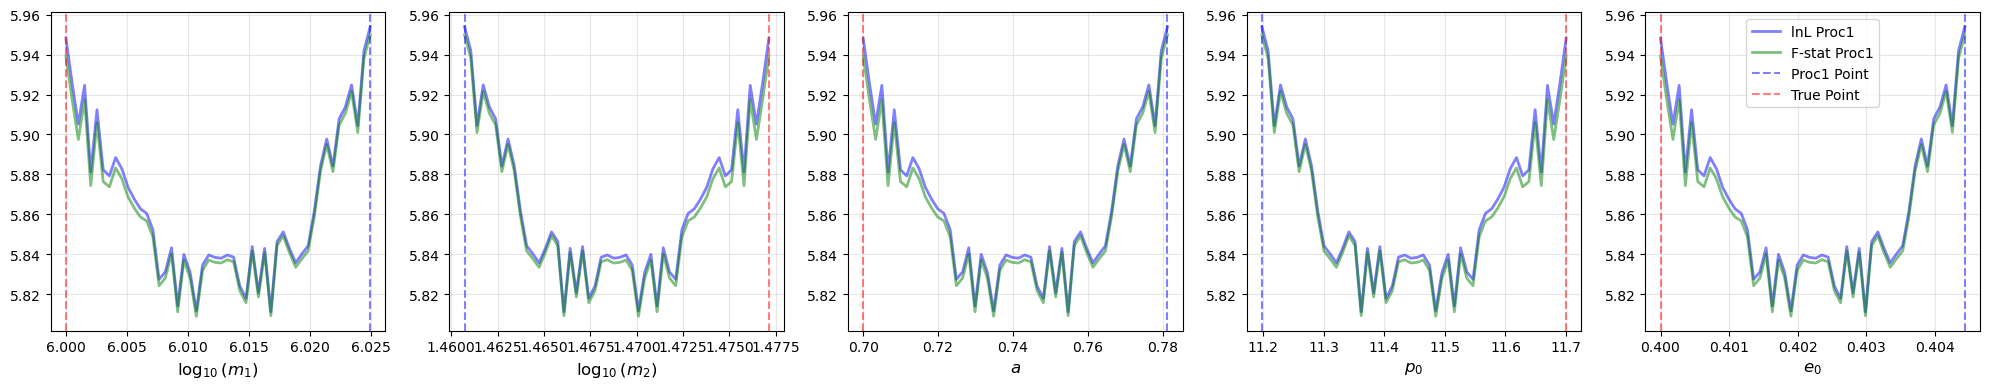

In [24]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
for dim in range(5):
    ax = axs_1d[dim]

    ax.plot(line_points_proc1[dim], logden_theory_proc1/10, '-',
            color='blue', alpha=0.5, linewidth=2, label='lnL Proc1')
    ax.plot(line_points_proc1[dim], f_theory, '-',
            color='green', alpha=0.5, linewidth=2, label='F-stat Proc1')

    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--',
               alpha=0.5, label='Proc1 Point')
    ax.axvline(param_true[dim], color='red', linestyle='--',
               alpha=0.5, label='True Point')

    ax.set_xlabel(labels[dim], fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()

In [25]:
Xm_proc1

[array([0.28428567, 0.55084646, 1.09772522, 1.64435692, 2.74892952,
        3.59088228, 2.70459467]),
 array([0.28450983, 0.54877933, 1.09449933, 1.64201768, 2.74595346,
        3.58072245, 2.70391762]),
 array([0.28453854, 0.55039698, 1.09307617, 1.64248757, 2.74608677,
        3.57413803, 2.69732059]),
 array([0.28460792, 0.55248903, 1.08949796, 1.63653179, 2.74404446,
        3.57355379, 2.69337627]),
 array([0.28458746, 0.5534316 , 1.08989244, 1.63295478, 2.73617594,
        3.57221011, 2.6910321 ]),
 array([0.28448414, 0.55420187, 1.09004028, 1.63108441, 2.73377733,
        3.56842206, 2.69036783]),
 array([0.28432903, 0.55393195, 1.09162766, 1.63068177, 2.72780894,
        3.55925317, 2.68691534]),
 array([0.28413605, 0.55312152, 1.09297278, 1.63059295, 2.72785473,
        3.5552397 , 2.68273365]),
 array([0.28390512, 0.55200923, 1.09217686, 1.62922738, 2.72766581,
        3.55307851, 2.67808418]),
 array([0.28362465, 0.55090765, 1.09035263, 1.63048098, 2.72857645,
        3.5530

In [26]:
X_scalars_proc1 = []
for i in range(len(Xm_proc1)):
    print('===')
    X_modes = Xm_proc1[i]          
    print('X_m: ', X_modes)
    rho_m = rhostats_proc1[i]     
    print('rho_m: ', rho_m)

    Xdotrho = cp.sum(X_modes * rho_m)
    print('Xdotrho: ', Xdotrho)
    rho_tot = cp.sqrt(cp.sum(cp.array(rho_m)**2))
    print('rho_tot: ', rho_tot)
    X_scalar = Xdotrho / rho_tot
    print('X_scalar: ', X_scalar)

    X_scalars_proc1.append(X_scalar.get())

X_scalars_proc1 = np.array(X_scalars_proc1)


===
X_m:  [0.28428567 0.55084646 1.09772522 1.64435692 2.74892952 3.59088228
 2.70459467]
rho_m:  [0.27849912 0.52145581 1.05868239 1.58574349 2.65593238 3.47660332
 2.62516783]
Xdotrho:  31.021145178224483
rho_tot:  5.478788402527555
X_scalar:  5.6620447622896615
===
X_m:  [0.28450983 0.54877933 1.09449933 1.64201768 2.74595346 3.58072245
 2.70391762]
rho_m:  [0.27939501 0.52121289 1.05806105 1.58685261 2.65459931 3.47467843
 2.62368962]
Xdotrho:  30.954714403896475
rho_tot:  5.476436223682896
X_scalar:  5.652346368982176
===
X_m:  [0.28453854 0.55039698 1.09307617 1.64248757 2.74608677 3.57413803
 2.69732059]
rho_m:  [0.28013322 0.52156949 1.05662056 1.58758214 2.6540979  3.47291931
 2.62210601]
Xdotrho:  30.903066274260713
rho_tot:  5.474323474555687
X_scalar:  5.645093209763038
===
X_m:  [0.28460792 0.55248903 1.08949796 1.63653179 2.74404446 3.57355379
 2.69337627]
rho_m:  [0.28067441 0.52242548 1.05521503 1.58722179 2.65383966 3.47151477
 2.62059026]
Xdotrho:  30.861844446141916


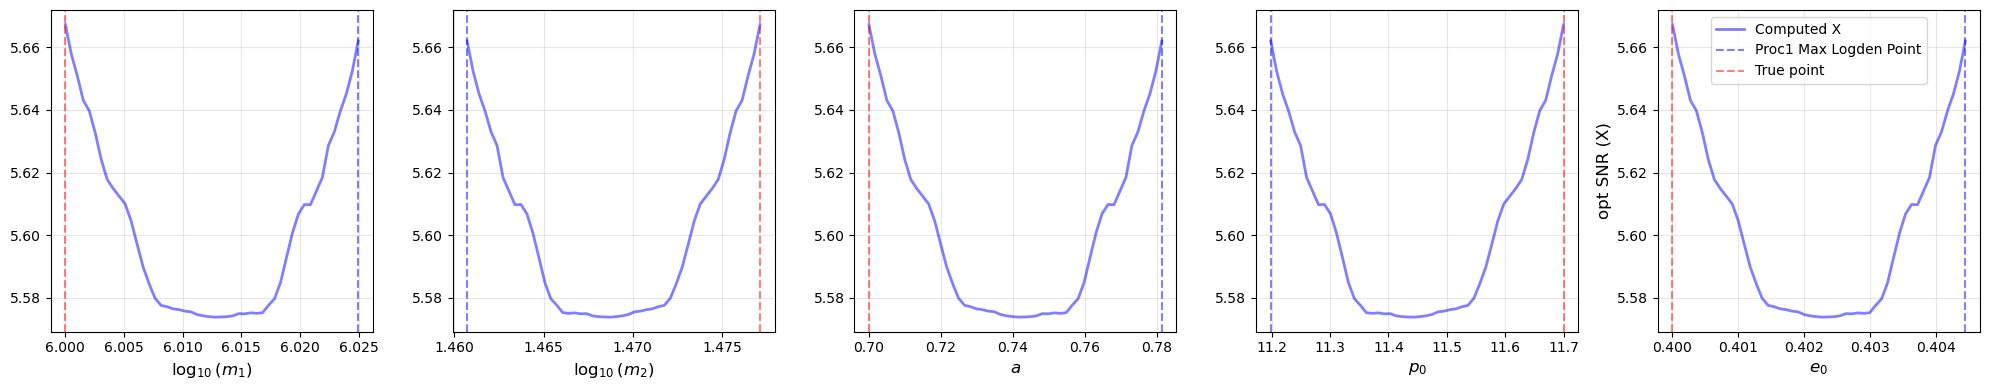

In [27]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
plt.ylabel('opt SNR (X)', fontsize=12)

for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], X_scalars_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed X')
#     ax.plot(line_points_proc2[dim], X_proc2, '-', 
#             color='darkorange', alpha=0.5, linewidth=2, label='Theory Proc2')
    

    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
#     ax.axvline(proc2_maxld_pt_1d[dim], color='orange', linestyle='--', 
#                alpha=0.5, label=f'Proc2 point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('opt SNR (X)', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()
